In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import astropy.units as u
from astropy.io import fits
from pathlib import Path
from IPython.display import clear_output
from importlib import reload
import copy
import ray
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
import os
from pathlib import Path

import poppy
inter = poppy.poppy_core.PlaneType.intermediate

import logging, sys
poppy_log = logging.getLogger('poppy')
poppy_log.setLevel('DEBUG')
logging.basicConfig(stream=sys.stdout, level=logging.INFO)
poppy_log.disabled = True

from scoob_llowfsc.imshows import imshow1, imshow2, imshow3


In [69]:
npix = 256
oversample = 4

pupil_diam = 10*u.mm
f1 = 400*u.mm
f2 = 100*u.mm

d_pupil_lens1 = 200*u.mm
d_lens1_ifp = f1
d_ifp_lens2 = f2
d_lens2_lens2BFP = f2

relay_ratio = f2/f1
d_pupil_lens1FFP = d_pupil_lens1 - f1
d_lens2BFP_pupil = - (relay_ratio)**2 * d_pupil_lens1FFP
print(d_lens2BFP_pupil)

APERTURE = poppy.CircularAperture(radius=pupil_diam/2, name='Pupil')
L1 = poppy.QuadraticLens(f_lens=f1, name='Lens 1')
L2 = poppy.QuadraticLens(f_lens=f2, name='Lens 2')
IFP = poppy.ScalarTransmission(name='Intermediate Focal Plane')
L2_BFP = poppy.ScalarTransmission(name='L2 BFP')
PUPIL_RELAY = poppy.ScalarTransmission(name='Relayed Pupil Plane')

12.5 mm


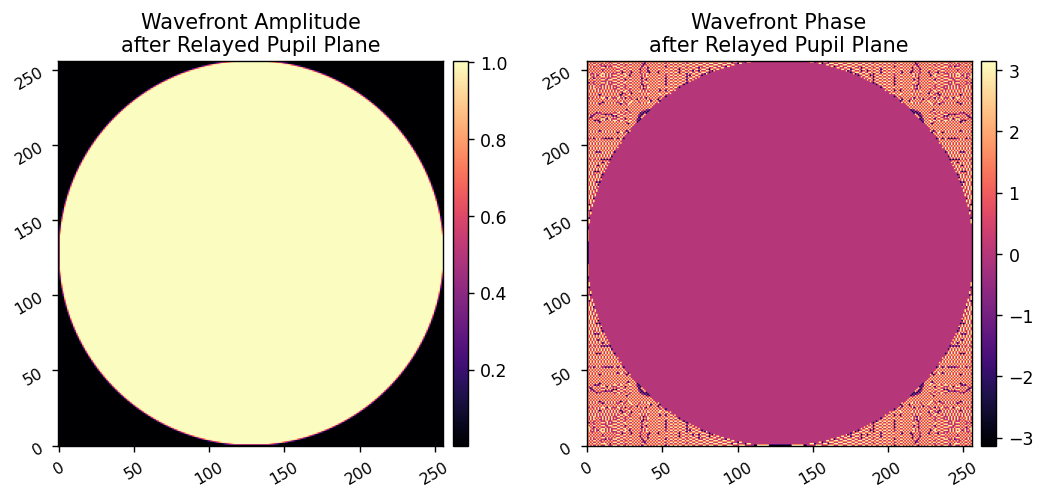

In [68]:
fosys = poppy.FresnelOpticalSystem(pupil_diameter=pupil_diam, npix=npix, beam_ratio=1/oversample, name='Pupil Relay System')
fosys.add_optic(APERTURE)
fosys.add_optic(L1, distance=d_pupil_lens1)
fosys.add_optic(IFP, distance=d_lens1_ifp)
fosys.add_optic(L2, distance=d_ifp_lens2)
fosys.add_optic(L2_BFP, distance=d_lens2_lens2BFP)
fosys.add_optic(PUPIL_RELAY, distance=d_lens2BFP_pupil)

_, pwfs = fosys.calc_psf(wavelength=633*u.nm, normalize='none', return_intermediates=True)
imshow2(
    pwfs[-1].amplitude, pwfs[-1].phase, 
    f'Wavefront Amplitude\n{pwfs[-1].location}', f'Wavefront Phase\n{pwfs[-1].location}',
    # lognorm1=1, 
    npix=npix, 
)

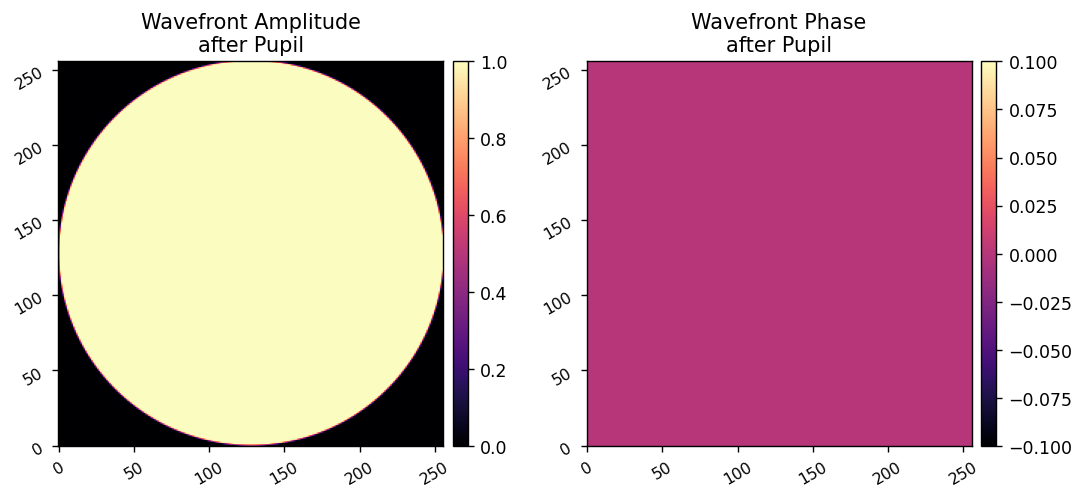

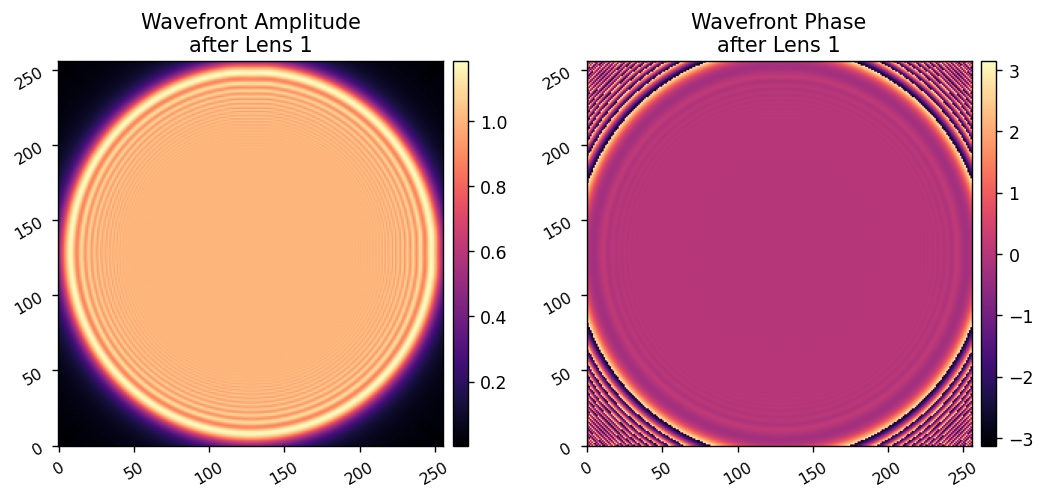

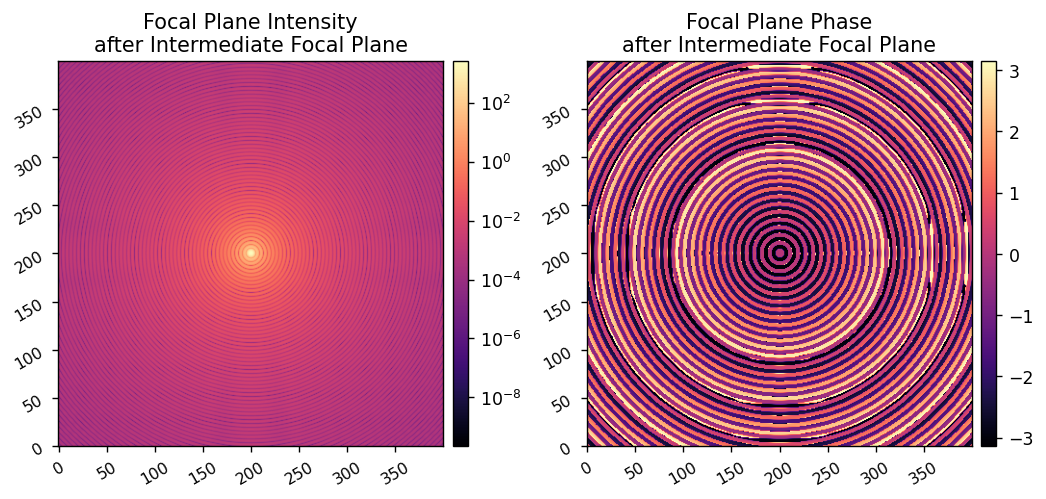

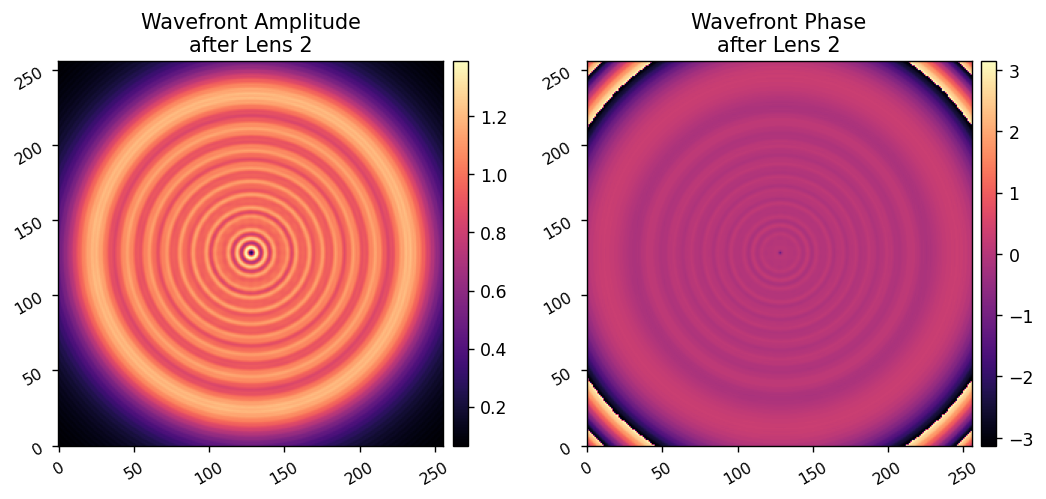

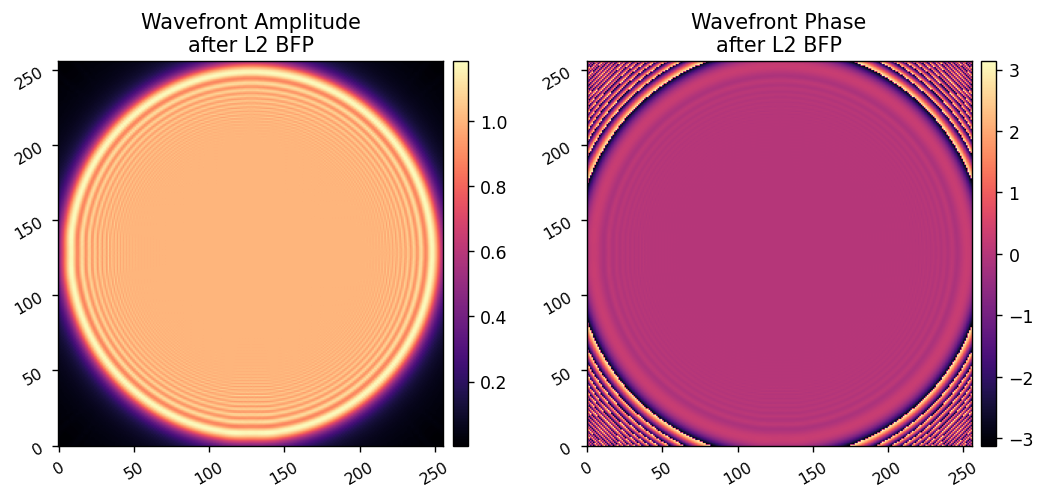

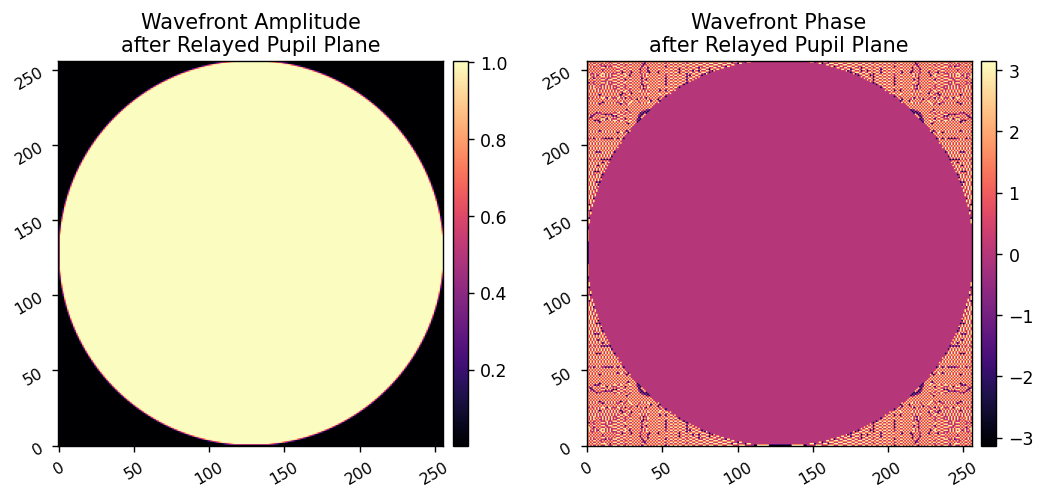

In [67]:
for i in range(len(pwfs)):
    pwf = pwfs[i]
    if 'focal' in pwf.location.lower():
        imshow2(
            pwf.intensity, pwf.phase, 
            f'Focal Plane Intensity\n{pwf.location}', f'Focal Plane Phase\n{pwf.location}',
            lognorm1=1, 
            npix=400, 
        )
    else:
        imshow2(
            pwf.amplitude, pwf.phase, 
            f'Wavefront Amplitude\n{pwf.location}', f'Wavefront Phase\n{pwf.location}',
            # lognorm1=1, 
            npix=npix, 
        )